In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
df = pd.read_csv('Titanic.csv')
df
df = df.drop(['deck', 'adult_male', 'who', 'Unnamed: 0', 'embarked', 'alive'], axis=1)
df['age']= df['age'].fillna(round(df['age'].mean()))
columns = df[['embark_town','class', 'alone', 'sex' ]] 
le = LabelEncoder()
for col in columns:
    df[col] = le.fit_transform(df[col])

x = df.drop(['survived'], axis=1)
y= df['survived']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

for_scale = ['fare', 'age']
scaler = StandardScaler()

x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

x_train_scaled[for_scale] = scaler.fit_transform(x_train_scaled[for_scale])
x_test_scaled[for_scale] = scaler.transform(x_test_scaled[for_scale])

model_list = {'Rf': RandomForestClassifier(random_state=42, class_weight='balanced').fit(x_train_scaled, y_train),
'Lg': LogisticRegression(random_state=42, class_weight='balanced').fit(x_train_scaled, y_train),
'XGB': XGBClassifier(random_state=42).fit(x_train_scaled, y_train),
'DC' :DecisionTreeClassifier(random_state=42).fit(x_train_scaled, y_train)}
df

# importances = pd.Series(xgb_after_grid_params.feature_importances_, index=x_train.columns)
# importances.sort_values(ascending=False)


,survived,pclass,sex,age,sibsp,parch,fare,class,embark_town,alone
0,0,3,1,22.0,1,0,7.2500,2,2,0
1,1,1,0,38.0,1,0,71.2833,0,0,0
2,1,3,0,26.0,0,0,7.9250,2,2,1
3,1,1,0,35.0,1,0,53.1000,0,2,0
4,0,3,1,35.0,0,0,8.0500,2,2,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,1,2,1
887,1,1,0,19.0,0,0,30.0000,0,2,1
888,0,3,0,30.0,1,2,23.4500,2,2,0
889,1,1,1,26.0,0,0,30.0000,0,0,1


In [17]:
def model_f1(model_list):
    for name, model in model_list.items():
        model_pred = model.predict(x_test_scaled)
        print(f'f1 {name}: {f1_score(y_test, model_pred)}')
model_f1(model_list)

f1 Rf: 0.723404255319149
f1 Lr: 0.7634408602150538
f1 XGB: 0.7222222222222222
f1 DC: 0.6519337016574586


In [18]:
def model_accuracy(model_list):
    for name, model in model_list.items():
        model_pred = model.predict(x_test_scaled)
        print(f'accuracy {name}: {accuracy_score(y_test, model_pred)}')

model_accuracy(model_list)

accuracy Rf: 0.7668161434977578
accuracy Lr: 0.8026905829596412
accuracy XGB: 0.7757847533632287
accuracy DC: 0.7174887892376681


In [20]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [26]:
xgb = XGBClassifier()
param_grid_xgb = {
    'n_estimators': [200, 300],         # number of trees
     'max_depth': [7, 10],                  # tree depth
     'learning_rate': [0.05, 0.1],      # small to medium steps
     'min_child_weight': [1, 3],          # balance small leaves
     'subsample': [0.8],          # row sampling for regularization
     'colsample_bytree': [0.8],   # feature sampling for regularization
     'scale_pos_weight': [3]   }               # 77/23 imbalance ratio
grid = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='f1').fit(x_train_scaled, y_train)
best_params = grid.best_params_
best_model = grid.best_estimator_
xgb_pred = best_model.predict(x_test_scaled)
print(f'f1_xgb: {f1_score(y_test, xgb_pred)}')
print(best_params)

f1_xgb: 0.751269035532995
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 10, 'min_child_weight': 3, 'n_estimators': 300, 'scale_pos_weight': 3, 'subsample': 0.8}


In [27]:
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample', None]
}
grid = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='f1', n_jobs=-1).fit(x_train_scaled, y_train)
best_params = grid.best_params_
best_model_rf = grid.best_estimator_
rf_pred = best_model_rf.predict(x_test_scaled)
print(f'f1_rf: {f1_score(y_test, rf_pred)}')
print(best_params)

f1_rf: 0.7650273224043715
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [127]:
import warnings
warnings.filterwarnings('ignore')
lg = LogisticRegression(random_state=42)
param_grid_lg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],          # Կարգավորման (regularization) ուժը
    'penalty': ['l1', 'l2'],                       # Կարգավորման տեսակը
    'solver': ['liblinear', 'saga']                # Ալգորիթմ, որը աշխատում է և՛ l1, և՛ l2-ի հետ
}

grid = GridSearchCV(estimator=lg, param_grid=param_grid_lg, cv=5, scoring='f1', n_jobs=-1).fit(x_train_scaled, y_train)
best_params = grid.best_params_
best_model_lg = grid.best_estimator_
lg_pred = best_model_lg.predict(x_test_scaled)
print(f'f1_lg: {f1_score(y_test, lg_pred)}')
print(best_params)

f1_lg: 0.7398843930635838
{'C': 1, 'penalty': 'l2', 'solver': 'saga'}


In [163]:
after_grid = {'xgb_after_grid_params' : XGBClassifier(colsample_bytree = 0.8, learning_rate = 0.05, max_depth= 10, min_child_weight= 3, n_estimators= 300, scale_pos_weight=3, subsample= 0.8).fit(x_train_scaled, y_train),
'rf_after_grid_params' : RandomForestClassifier(class_weight= 'balanced', max_depth= 10, min_samples_leaf= 2, min_samples_split= 10, n_estimators= 100, random_state=42).fit(x_train_scaled, y_train),
'lg_after_grid_params' : LogisticRegression(C= 1, penalty = 'l2', solver= 'saga').fit(x_train_scaled, y_train)}

print(model_f1(after_grid))
print(model_accuracy(after_grid))


f1 xgb_after_grid_params: 0.751269035532995
f1 rf_after_grid_params: 0.7650273224043715
f1 lg_after_grid_params: 0.7398843930635838
None
accuracy xgb_after_grid_params: 0.7802690582959642
accuracy rf_after_grid_params: 0.8071748878923767
accuracy lg_after_grid_params: 0.7982062780269058
None


In [ ]:
grid_models = {'xgb_after_grid_params' : XGBClassifier(colsample_bytree = 0.7, learning_rate = 0.03, max_depth= 4, min_child_weight= 5, n_estimators= 200, scale_pos_weight=3, subsample= 0.8).fit(x_train_scaled, y_train),
'rf_after_grid_params' : RandomForestClassifier(class_weight= 'balanced', max_depth= 6, min_samples_leaf= 2, min_samples_split= 10, n_estimators= 100, random_state=42).fit(x_train_scaled, y_train),
'lg_after_grid_params' : LogisticRegression(C= 1, penalty = 'l2', solver= 'saga').fit(x_train_scaled, y_train)}
def Possible_Overfitting(x_train_scaled, x_test_scaled, y_train, y_test):
    for name, model in grid_models.items():
        train_preds = model.predict(x_train_scaled)
        print(f'{name} : {accuracy_score(y_train, train_preds)}')

    for name, model in grid_models.items():
        test_preds = model.predict(x_test_scaled)
        print(f'{name}, {accuracy_score(y_test, test_preds)}')

Possible_Overfitting(x_train_scaled, x_test_scaled, y_train, y_test)

xgb_after_grid_params : 0.8517964071856288
rf_after_grid_params : 0.8697604790419161
lg_after_grid_params : 0.8008982035928144
xgb_after_grid_params, 0.7892376681614349
rf_after_grid_params, 0.820627802690583
lg_after_grid_params, 0.7982062780269058


In [164]:
after_overfitting = {'xgb_after_grid_params' : XGBClassifier(colsample_bytree = 0.7, learning_rate = 0.03, max_depth= 4, min_child_weight= 5, n_estimators= 200, scale_pos_weight=3, subsample= 0.8).fit(x_train_scaled, y_train),
'rf_after_grid_params' : RandomForestClassifier(class_weight= 'balanced', max_depth= 6, min_samples_leaf= 2, min_samples_split= 10, n_estimators= 100, random_state=42).fit(x_train_scaled, y_train),
'lg_after_grid_params' : LogisticRegression(C= 1, penalty = 'l2', solver= 'saga').fit(x_train_scaled, y_train)}

print(model_f1(after_overfitting))
print(model_accuracy(after_overfitting))

f1 xgb_after_grid_params: 0.7638190954773869
f1 rf_after_grid_params: 0.7777777777777778
f1 lg_after_grid_params: 0.7398843930635838
None
accuracy xgb_after_grid_params: 0.7892376681614349
accuracy rf_after_grid_params: 0.820627802690583
accuracy lg_after_grid_params: 0.7982062780269058
None


In [168]:
xgb_after_overfitting= XGBClassifier(colsample_bytree = 0.7, learning_rate = 0.03, max_depth= 4, min_child_weight= 5, n_estimators= 200, scale_pos_weight=3, subsample= 0.8).fit(x_train_scaled, y_train)
rf_after_overfitting = RandomForestClassifier(class_weight= 'balanced', max_depth= 6, min_samples_leaf= 2, min_samples_split= 10, n_estimators= 100, random_state=42).fit(x_train_scaled, y_train)
lg_after_overfitting = LogisticRegression(C= 1, penalty = 'l2', solver= 'saga').fit(x_train_scaled, y_train)

In [185]:
y_proba = xgb_after_overfitting.predict_proba(x_test_scaled)[:, 1]
threshold = 0.6
xgb_pred_new = (y_proba >= threshold).astype(int)
print('xgb f1_score after treshhold:' , f1_score(y_test, xgb_pred_new))
print('xgb accuracy  after treshhold:' , accuracy_score(y_test, xgb_pred_new))

xgb f1_score after treshhold: 0.7724867724867724
xgb accuracy  after treshhold: 0.8071748878923767


In [175]:
y_proba = rf_after_overfitting.predict_proba(x_test_scaled)[:, 1]
threshold = 0.5
rf_pred_new = (y_proba >= threshold).astype(int)
print('rf f1_score after treshhold:' , f1_score(y_test, rf_pred_new))
print('rf accuracy  after treshhold:' , accuracy_score(y_test, rf_pred_new))

rf f1_score after treshhold: 0.7777777777777778
rf accuracy  after treshhold: 0.820627802690583


In [169]:
y_proba = lg_after_overfitting.predict_proba(x_test_scaled)[:, 1]
threshold = 0.35
rf_pred_new = (y_proba >= threshold).astype(int)
print('lg f1_score after treshhold:' , f1_score(y_test, rf_pred_new))
print('lg accuracy  after treshhold:' , accuracy_score(y_test, rf_pred_new))

lg f1_score after treshhold: 0.7755102040816326
lg accuracy  after treshhold: 0.8026905829596412


In [186]:
# the best model is
# rf_after_overfitting - treshold = 0.5



<Axes: xlabel='new', ylabel='count'>

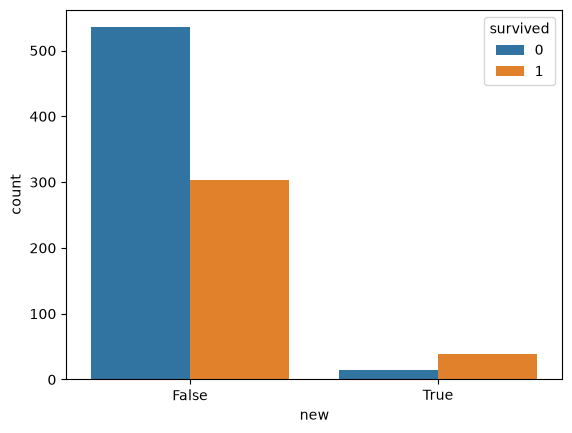

In [3]:
df['new'] = df['fare']>100
df
sns.countplot(data=df, x='new', hue='survived')

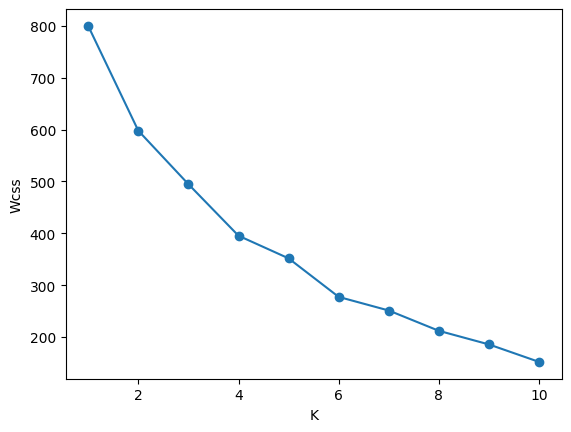

cumulative_variance [0.33690046 0.5992069  0.83181329 1.        ]


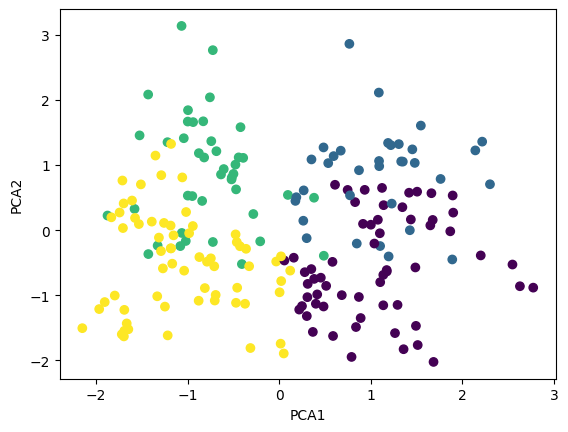

In [14]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
df = pd.read_csv('/home/armen/Downloads/Mall_Customers.csv')
df = df.drop('CustomerID', axis=1)
le = LabelEncoder()
df['Gender']= le.fit_transform(df['Gender'])
df
x = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)' ]]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
wcss = []
for k in range(1,11):
    kmeans= KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('K')
plt.ylabel('Wcss')
plt.show()
k=4
pca = PCA().fit(x_scaled)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print('cumulative_variance' , cumulative_variance)
model = KMeans(n_clusters=k, init='k-means++', random_state=42)
df['Cluster_Raw']= model.fit_predict(x_scaled)

pca_2= PCA(n_components=2)
x_pca2 = pca_2.fit_transform(x_scaled)

df['PCA1']= x_pca2[: , 0]
df['PCA2']= x_pca2[: , 1]

plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster_Raw'], cmap='viridis')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()







In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
x= df.drop('AveRooms', axis=1)
y= df['AveRooms']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)
scaler= StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

lr = LinearRegression().fit(x_train, y_train)
rf = RandomForestRegressor()
xgb = XGBRegressor().fit(x_train, y_train)

lr_pred = lr.predict(x_test)
# rf_pred = rf.predict(x_test)
xgb_pred = xgb.predict(x_test)

params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10,  None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

grid = GridSearchCV(rf, params, cv=5, scoring='r2', n_jobs=-1).fit(x_train, y_train)
best_model = grid.best_estimator_
best_params = grid.best_params_
rf_grid_pred = best_model.predict(x_test)

print('mse lr' , mean_squared_error(y_test, lr_pred))
print('mae lr' , mean_absolute_error(y_test, lr_pred))
print('r2 lr' , r2_score(y_test, lr_pred))
# print('mse rf' , mean_squared_error(y_test, rf_pred))
# print('mae rf' , mean_absolute_error(y_test, rf_pred))
# print('r2 rf' , r2_score(y_test, rf_pred))
print('mse xgb' , mean_squared_error(y_test, xgb_pred))
print('mae xgb' , mean_absolute_error(y_test, xgb_pred))
print('r2 xgb' , r2_score(y_test, xgb_pred))
print('r2 grid rf' , r2_score(y_test, rf_grid_pred))


mse lr 0.815217779348977
mae lr 0.5948047132048793
r2 lr 0.8817219856619642
mse xgb 0.8366443656261214
mae xgb 0.4574994706269072
r2 xgb 0.878613253071604
r2 grid rf 0.7055526038454343
